In [64]:
# 結果の可視化関連の処理で使用
from IPython.display import Image
import cv2
import numpy as np

# 画像/動画のセグメンテーションで使用
from ultralytics import SAM

# 自動アノテーションで使用
from ultralytics.data.annotator import auto_annotate
from ultralytics.utils.plotting import colors

In [61]:
# モデル読み込み
model = SAM("sam2_l.pt")

# モデル概要情報の表示
model.info()

Model summary: 854 layers, 224,430,130 parameters, 224,430,130 gradients


(854, 224430130, 224430130, 0.0)

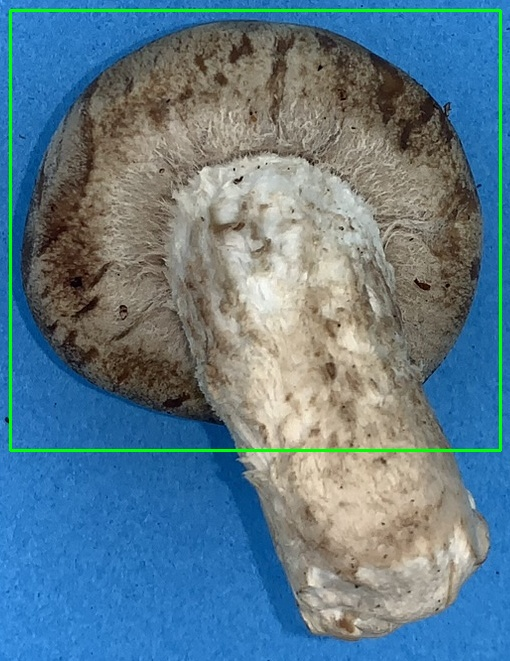

In [76]:
cv2.imwrite("show_box.jpg", cv2.rectangle(cv2.imread("/home/data/0327_jikuari/cropBB/A/IMG_1829.JPEG"), (10, 10), (500, 450), color=(0, 255, 0), thickness=2))
Image("show_box.jpg")


image 1/1 /home/data/0327_jikuari/cropBB/A/IMG_1829.JPEG: 1024x1024 1 0, 82.3ms
Speed: 9.9ms preprocess, 82.3ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 1024)


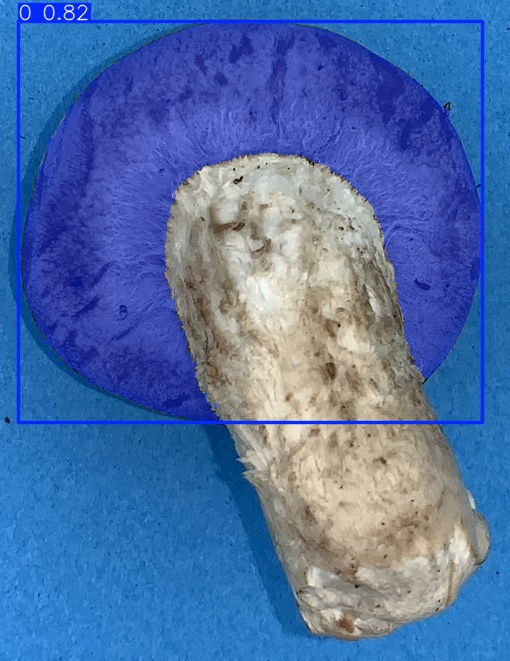

In [77]:
# 矩形指定のプロンプトでセグメンテーションを実行
box_results = model("/home/data/0327_jikuari/cropBB/A/IMG_1829.JPEG", bboxes=[10, 10, 500, 450])

# 結果を保存
box_results[0].save("box_result.jpg")
Image("box_result.jpg")


image 1/1 /home/src/maesyori/IMG_1691.JPEG: 576x640 1 bowl, 2.5ms
Speed: 0.9ms preprocess, 2.5ms inference, 0.4ms postprocess per image at shape (1, 3, 576, 640)


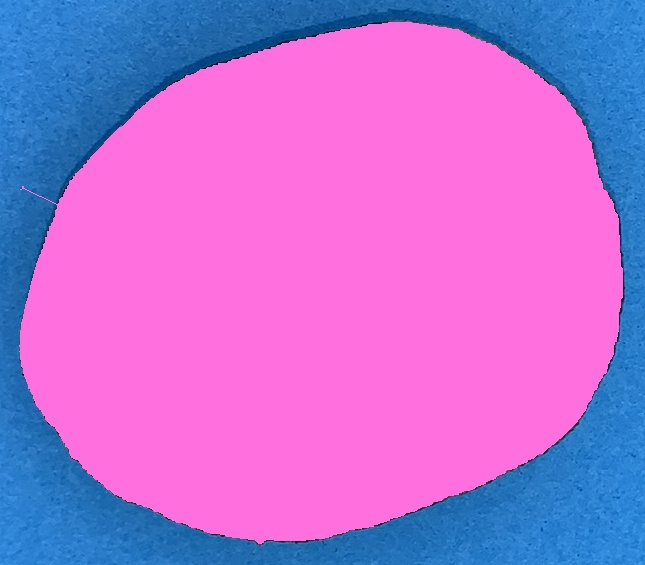

In [52]:
# 物体検出にYOLOv8のXサイズ、SAMのモデルにSAM2のLサイズを指定
auto_annotate(data="/home/src/maesyori/IMG_1691.JPEG", det_model="/home/src/yolo/yolov8n.pt", sam_model="sam2_l.pt")
img = cv2.imread("/home/src/maesyori/IMG_1691.JPEG")
img_h, img_w = img.shape[:2]

# 自動アノテーション結果のtxtファイル読み込み
with open("/home/src/maesyori/IMG_1691_auto_annotate_labels/IMG_1691.txt") as f:
    lines = f.readlines()

cls_ids = []
poly_points_list = []
for line in lines:
    cols = line.replace("\n", "").split(" ")
    cls_ids.append(int(cols[0]))  # クラスID
    poly_cols = cols[1:]  # マスクの輪郭座標
    assert len(poly_cols) % 2 == 0
    poly_points_list.append(
        [(int(float(poly_cols[2*n])*img_w), int(float(poly_cols[2*n+1])*img_h)) for n in range(int(len(poly_cols) / 2))]
    )

anno_img = img.copy()
for idx, cls_id in enumerate(cls_ids):
    cv2.fillConvexPoly(anno_img, np.array(poly_points_list[idx]), colors(cls_id, True))

cv2.imwrite("auto_annotate_result.jpg", anno_img)
Image("auto_annotate_result.jpg")